# Evaluate Model 

In [1]:
import torch
import torch.nn as nn
from torchvision import models
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, average_precision_score
from Load_dataset import test_loader  
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


# Load Pretrained Model b4 fine tuned
model_before = models.resnext50_32x4d(weights=models.ResNeXt50_32X4D_Weights.IMAGENET1K_V1)
model_before.fc = nn.Sequential(
    nn.Linear(model_before.fc.in_features, 512),
    nn.ReLU(),
    nn.BatchNorm1d(512),
    nn.Dropout(0.3),
    nn.Linear(512, 1)
)
model_before.load_state_dict(torch.load("model_b4_finetuned.pth")) 
model_before.eval()

# Load Fine-Tuned Model
model_after = models.resnext50_32x4d(weights=models.ResNeXt50_32X4D_Weights.IMAGENET1K_V1)
model_after.fc = nn.Sequential(
    nn.Linear(model_after.fc.in_features, 512),
    nn.ReLU(),
    nn.BatchNorm1d(512),
    nn.Dropout(0.3),
    nn.Linear(512, 1)
)
model_after.load_state_dict(torch.load("model_finetuned.pth"))  # Load fine-tuned model
model_after.eval()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_before = model_before.to(device)
model_after = model_after.to(device)





Class Mapping: {'fake': 0, 'real': 1}
Train dataset: 140002 images
Validation dataset: 39428 images
Test dataset: 10905 images
Batch of images shape: torch.Size([32, 3, 224, 224])
Batch of labels: tensor([0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0,
        0, 1, 0, 0, 0, 0, 0, 0])


In [2]:
def evaluate_model(model, test_loader):
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device).float()
            outputs = model(images).squeeze()
            predictions = (torch.sigmoid(outputs) > 0.5).float()

            all_preds.extend(predictions.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Calculate metrics
    accuracy = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds)
    recall = recall_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds)

    return accuracy, precision, recall, f1


## Before fine tune

In [ ]:
# Evaluate Pretrained Model
acc_before, prec_before, rec_before, f1_before = evaluate_model(model_before, test_loader)
print(f" Accuracy: {acc_before:.4f}, Precision: {prec_before:.4f},Recall: {rec_before:.4f}, F1 Score: {f1_before:.4f}")


 Accuracy: 0.7872, Precision: 0.7971, Recall: 0.7663, F1 Score: 0.7814


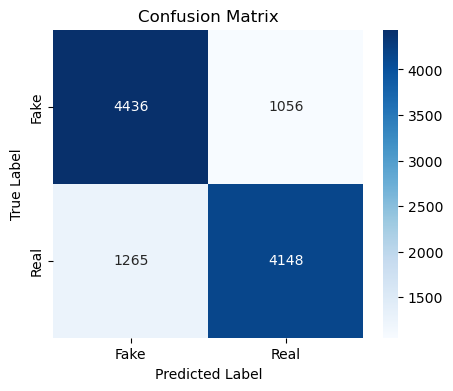

In [4]:
# Compute confusion matrix
y_true = []
y_pred = [] 

model_before.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device).float()
        outputs = model_before(images).squeeze()
        predictions = (torch.sigmoid(outputs) > 0.5).float()
        
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predictions.cpu().numpy())

# Generate confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot confusion matrix
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Fake", "Real"], yticklabels=["Fake", "Real"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()


In [5]:
# Compute probabilities for ROC AUC and AP Score
y_probs = []  
y_true = []   

model_before.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device).float()
        outputs = model_before(images).squeeze()
        probs = torch.sigmoid(outputs).cpu().numpy() 
        
        y_probs.extend(probs)  
        y_true.extend(labels.cpu().numpy())  


roc_auc = roc_auc_score(y_true, y_probs)
ap_score = average_precision_score(y_true, y_probs)


print(f" ROC AUC Score: {roc_auc:.4f}")
print(f" Average Precision Score (AP): {ap_score:.4f}")




 ROC AUC Score: 0.8732
 Average Precision Score (AP): 0.8731


## Fine-tuned model 

In [6]:
# Evaluate Fine-Tuned Model
acc_after, prec_after, rec_after, f1_after = evaluate_model(model_after, test_loader)
print(f" Accuracy: {acc_after:.4f}, Precision: {prec_after:.4f}, Recall: {rec_after:.4f}, F1 Score: {f1_after:.4f}")

 Accuracy: 0.7880, Precision: 0.7951, Recall: 0.7718, F1 Score: 0.7833


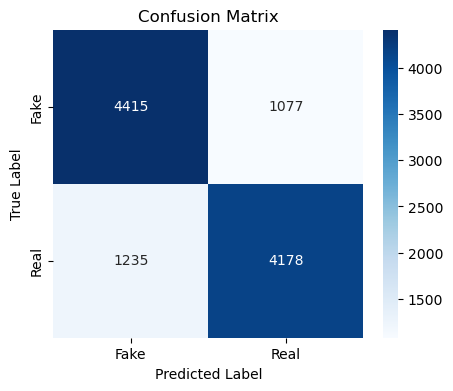

In [7]:
# Compute confusion matrix
y_true = []
y_pred = []  

model_after.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device).float()
        outputs = model_after(images).squeeze()
        predictions = (torch.sigmoid(outputs) > 0.5).float()
        
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predictions.cpu().numpy())

# Generate confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot confusion matrix
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Fake", "Real"], yticklabels=["Fake", "Real"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()


In [8]:
# Compute probabilities for ROC AUC and AP Score
y_probs = []  
y_true = []  

model_after.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device).float()
        outputs = model_after(images).squeeze()
        probs = torch.sigmoid(outputs).cpu().numpy()  
        
        y_probs.extend(probs)  
        y_true.extend(labels.cpu().numpy())  

roc_auc = roc_auc_score(y_true, y_probs)
ap_score = average_precision_score(y_true, y_probs)

print(f" ROC AUC Score: {roc_auc:.4f}")
print(f" Average Precision Score (AP): {ap_score:.4f}")

 ROC AUC Score: 0.8724
 Average Precision Score (AP): 0.8728


## Compare model

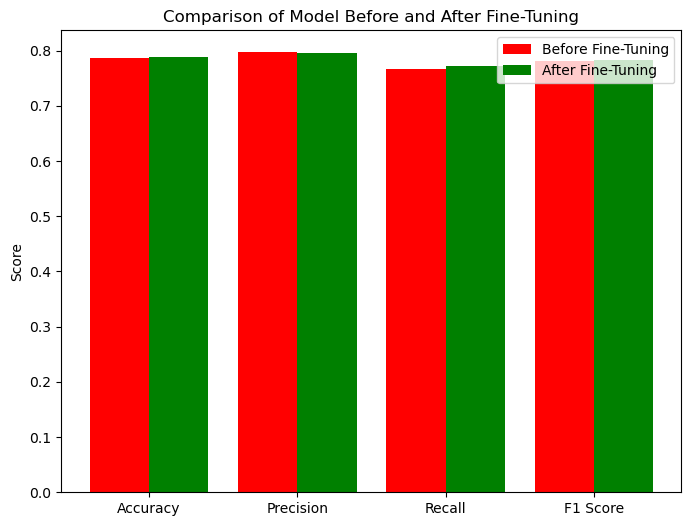

 Before Fine-Tuning:
 Accuracy: 0.7872, Precision: 0.7971, Recall: 0.7663, F1 Score: 0.7814
 After Fine-Tuning:
 Accuracy: 0.7880, Precision: 0.7951, Recall: 0.7718, F1 Score: 0.7833


In [9]:
# Define metric names and values
metrics = ["Accuracy", "Precision", "Recall", "F1 Score"]
before_values = [acc_before, prec_before, rec_before, f1_before]
after_values = [acc_after, prec_after, rec_after, f1_after]

x = np.arange(len(metrics))

plt.figure(figsize=(8, 6))
plt.bar(x - 0.2, before_values, 0.4, label="Before Fine-Tuning", color="red")
plt.bar(x + 0.2, after_values, 0.4, label="After Fine-Tuning", color="green")
plt.xticks(x, metrics)
plt.ylabel("Score")
plt.title("Comparison of Model Before and After Fine-Tuning")
plt.legend()
plt.show()


print(f" Before Fine-Tuning:")
print(f" Accuracy: {acc_before:.4f}, Precision: {prec_before:.4f}, Recall: {rec_before:.4f}, F1 Score: {f1_before:.4f}")
print(f" After Fine-Tuning:")
print(f" Accuracy: {acc_after:.4f}, Precision: {prec_after:.4f}, Recall: {rec_after:.4f}, F1 Score: {f1_after:.4f}")

# Test model with sample image

In [16]:
from PIL import Image
import torch
import torchvision.transforms as transforms

# Define Transformations (Same as Training)
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])  
])

# Load & Preprocess Image
image_path = "C:\\Users\\PC\\WX\\fake_342.jpg"
image = Image.open(image_path).convert("RGB") 

# Apply transformations
image = transform(image)
image = image.unsqueeze(0)  

# Set Model to Eval Mode
model_after.eval()
image = image.to(device)

# Make Prediction
with torch.no_grad():
    output = model_after(image).squeeze()  # Get model output (logits)
    probability = torch.sigmoid(output).item()  # Convert logits to probability
    prediction = 1 if probability > 0.5 else 0  # Apply same thresholding logic

# Print Results
if prediction == 1:
    print(f"Fake Image Detected! (Confidence: {probability:.4f})")
else:
    print(f"Real Image Detected! (Confidence: {1 - probability:.4f})")


Real Image Detected! (Confidence: 0.6395)
